ЧИСТОВИК. Признаков: 38
Fitting 5 folds for each of 25 candidates, totalling 125 fits

=== РЕЗУЛЬТАТЫ ФАЙН-ТЮНИНГА ===
R²: 0.9540
Лучшие параметры: {'model__alpha': 0.1, 'model__l1_ratio': 0.9}

Топ-5 выживших признаков:
                       feature   importance
6                  close_lag_1  4883.095629
7                  close_lag_2  4419.613954
8                  close_lag_3  3479.397541
9                  close_lag_4  3002.098039
2  MACD_Cross_Power_Normalized  2846.826108
L1 обнулила 0 признаков.


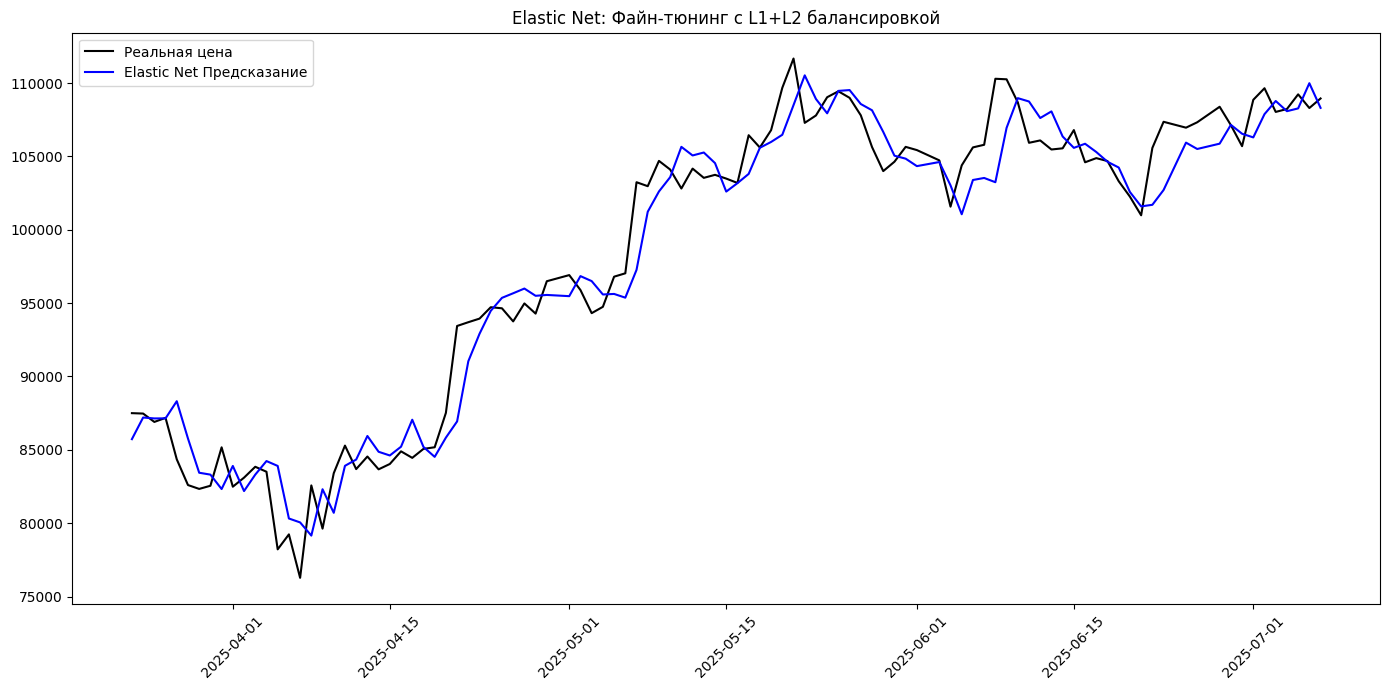

In [ ]:
#Считаю что стоит оставить потому что показывает что в нашем случае ридж дает меньшую ошибку на живом примере если у нас лассо не обнуил ничего 
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import matplotlib.pyplot as plt

# 1. Загрузка данных
df = pd.read_csv('../data/csv/main_data.csv')
df = df.drop_duplicates(subset=['date'], keep='first').reset_index(drop=True)
df = df[df['date'] >= '2024-01-01'].copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Инженерия признаков (с учетом выводов слепого теста)
df['hash_rate_ma_7'] = df['hash-rate'].rolling(7).mean()
df['volume_ma_7'] = df['volume'].rolling(window=7).mean()
df['volume_ratio_7d'] = df['volume'] / df['volume_ma_7']
df['active_count_ma_7'] = df['active-count'].rolling(window=7).mean()
df['hash_active_count_7dirived'] = df['hash_rate_ma_7'] / (df['active_count_ma_7'] * df['volume'])
df['hash_active_count_dirived14'] = df['hash_active_count_7dirived'].rolling(window=14).mean()
df['rsi_divergence'] = df['rsi'] - df['close']
df['macd_signal_diff'] = df['MACD'] - df['Signal_Line']

# 3. Возвращаем ВСЕ лаги, включая цены
features_to_lag = ['close', 'volume', 'rsi', 'MACD_Cross_Power_Normalized', 
                   'hash-rate', 'active-count', 'transfer_count', 'zew_mood_index']

def create_lag_features(data, columns, n_lags=4):
    d = data.copy()
    for col in columns:
        for lag in range(1, n_lags+1):
            d[f'{col}_lag_{lag}'] = d[col].shift(lag)
    return d

df = create_lag_features(df, features_to_lag)
df['target_close'] = df['close'].shift(-1)
df = df.dropna()

# Формирование списка фичей
selected_features = [
    'hash_active_count_dirived14', 'rsi', 'MACD_Cross_Power_Normalized', 
    'volume_ma_7', 'volume_ratio_7d', 'macd_signal_diff'
]
lag_cols = [col for col in df.columns if '_lag_' in col]
selected_features.extend(lag_cols)

X = df[selected_features]
y = df['target_close']

# 4. Разделение
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
test_dates = df.iloc[train_size:]['date']

# 5. Метрики и Сетка для Файн-Тюнинга
tscv = TimeSeriesSplit(n_splits=5, test_size=30, gap=7)

def NMAPE(y_true, y_pred):
    return 1 - np.mean(np.abs((y_true - y_pred) / y_true)) * 100

scoring = {'r2': 'r2', 'mape': make_scorer(NMAPE)}

elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(random_state=42, max_iter=20000, tol=1e-3))
])

# Адекватная сетка для баланса L1 и L2 с вернувшимися ценами
elastic_param_grid = {
    'model__alpha': [0.1, 0.5, 1.0, 5.0, 10.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9] # 0.1 - упор на L2 (сглаживание лагов), 0.9 - упор на L1 (удаление мусора)
}

print(f"Признаков: {len(selected_features)}")
grid_search = GridSearchCV(
    estimator=elastic_pipeline, param_grid=elastic_param_grid, 
    cv=tscv, scoring=scoring, refit='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 6. Оценка
predictions = best_model.predict(X_test)
print("\n=== РЕЗУЛЬТАТЫ ФАЙН-ТЮНИНГА ===")
print(f"R²: {r2_score(y_test, predictions):.4f}")
print(f"Лучшие параметры: {grid_search.best_params_}")

coefs = best_model.named_steps['model'].coef_
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': np.abs(coefs)
}).sort_values('importance', ascending=False)

print("\nТоп-5 выживших признаков:")
print(feature_importance.head(5))
print(f"L1 обнулила {len(feature_importance[feature_importance['importance'] == 0])} признаков.")

# 7. График
plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test.values, label='Реальная цена', color='black')
plt.plot(test_dates, predictions, label='Elastic Net Предсказание', color='blue')
plt.title('Elastic Net: Файн-тюнинг с L1+L2 балансировкой')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('elastic_v3_finetune.png')

Обучение ElasticNet_True (L1+L2)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits



=== ИТОГИ ELASTIC NET ===
Лучшие параметры: {'model__alpha': 10.0, 'model__l1_ratio': 0.99}
R²: 0.9399
MSE: 6171082.4045
NMAPE: -0.9643

=== РАБОТА L1-РЕГУЛЯРИЗАЦИИ ===
Использовано признаков (34 из 37):
rsi_divergence, close_lag_1, close_lag_4, close_lag_2, close_lag_3, rsi, MACD_Cross_Power_Normalized, macd_signal_diff, MACD_Cross_Power_Normalized_lag_2, MACD_Cross_Power_Normalized_lag_3, volume_lag_4, volume_lag_1, hash-rate_lag_1, hash-rate_lag_2, hash-rate_lag_3, volume_lag_2, transfer_count_lag_1, hash-rate_lag_4, MACD_Cross_Power_Normalized_lag_4, transfer_count_lag_3, transfer_count_lag_4, MACD_Cross_Power_Normalized_lag_1, hash_active_count_dirived14, total_fee_lag_3, volume_lag_3, total_fee_lag_4, rsi_lag_2, active-count_lag_4, transfer_count_lag_2, total_fee_lag_1, rsi_lag_4, active-count_lag_2, active-count_lag_1, total_fee_lag_2

УБИТО (обнулено) признаков (3 из 37):
rsi_lag_3, rsi_lag_1, active-count_lag_3

Графики сохранены: 'elasticnet_feature_importance.png' и 'elasti

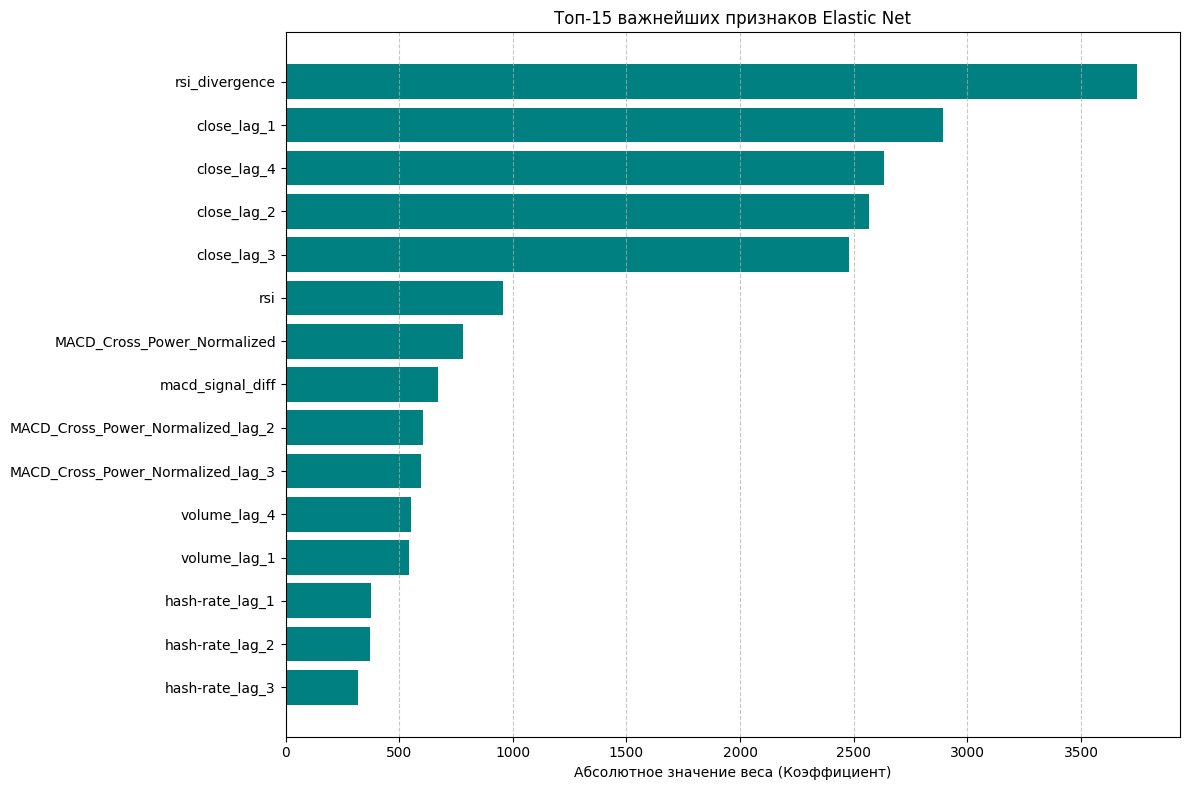

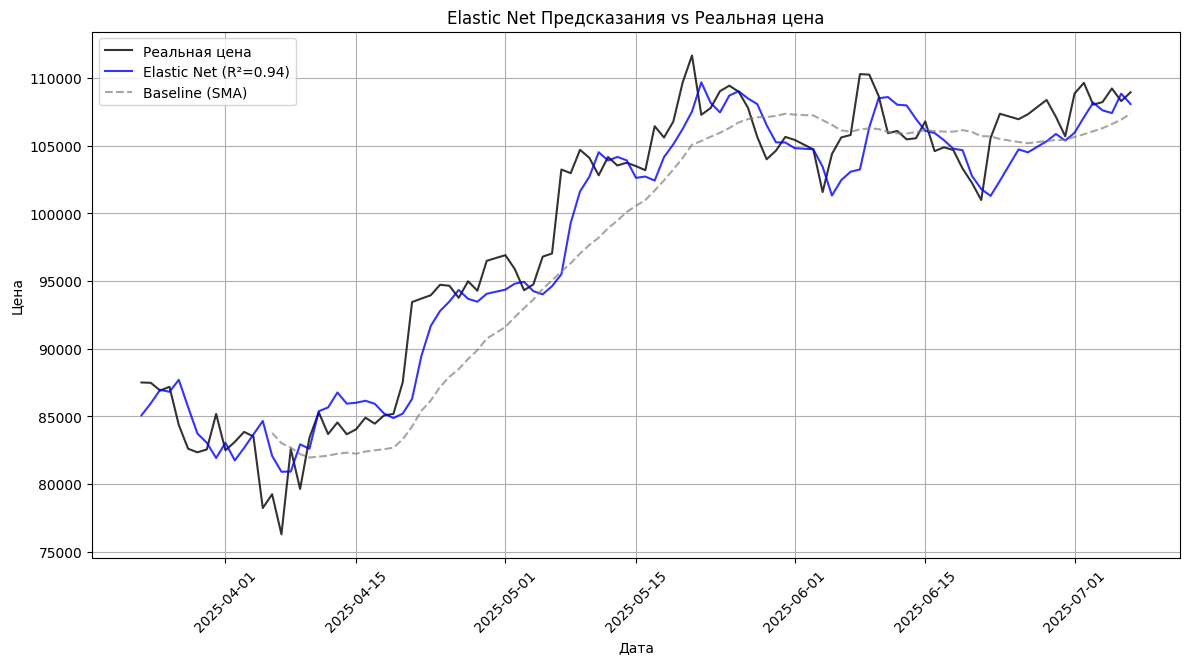

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import matplotlib.pyplot as plt

# 1. Загрузка и первичная очистка
df = pd.read_csv('../data/csv/main_data.csv')
df = df.drop_duplicates(subset=['date'], keep='first').reset_index(drop=True)
df = df[df['date'] >= '2024-01-01'].copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Генерация базовых признаков 
df['close_change'] = df['close'].pct_change(3)
df['hash_rate_ma_7'] = df['hash-rate'].rolling(7).mean()
df['volume_ma_7'] = df['volume'].rolling(window=7).mean()
df['active_count_ma_7'] = df['active-count'].rolling(window=7).mean()
df['hash_active_count_7dirived'] = df['hash_rate_ma_7'] / (df['active_count_ma_7'] * df['volume'])
df['hash_active_count_dirived14'] = df['hash_active_count_7dirived'].rolling(window=14).mean()
df['macd_signal_diff'] = df['MACD'] - df['Signal_Line']
df['rsi_divergence'] = df['rsi'] - df['close']

# 3. Генерация лагов
features_to_lag = ['close', 'volume', 'rsi', 'MACD_Cross_Power_Normalized', 
                   'hash-rate', 'active-count', 'total_fee', 'transfer_count']

def create_lag_features(data, columns, n_lags=4):
    d = data.copy()
    for col in columns:
        for lag in range(1, n_lags+1):
            d[f'{col}_lag_{lag}'] = d[col].shift(lag)
    return d

df = create_lag_features(df, features_to_lag)
df['target_close'] = df['close'].shift(-1)
df = df.dropna()

# Формирование итогового пула признаков
selected_features = [
    'hash_active_count_dirived14', 'rsi', 'MACD_Cross_Power_Normalized', 
    'macd_signal_diff', 'rsi_divergence'
]
lag_cols = [col for col in df.columns if '_lag_' in col]
selected_features.extend(lag_cols)

X = df[selected_features]
y = df['target_close']

# 4. Разделение выборки
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
test_dates = df.iloc[train_size:]['date']

# 5. Настройка валидации и пайплайна
tscv = TimeSeriesSplit(n_splits=5, test_size=30, gap=7)

def NMAPE(y_true, y_pred):
    return 1 - np.mean(np.abs((y_true - y_pred) / y_true)) * 100

scoring = {
    'r2': 'r2',
    'mape': make_scorer(NMAPE),
    'mse': 'neg_mean_squared_error'
}

elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(random_state=42, max_iter=50000, tol=1e-2)) 
])

param_grid = {
    'model__alpha': [10.0, 100.0, 500.0, 1000.0, 2000.0],
    'model__l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.99]
}

print("Обучение ElasticNet_True (L1+L2)...")
grid_search = GridSearchCV(
    estimator=elastic_pipeline, 
    param_grid=param_grid, 
    cv=tscv, 
    scoring=scoring, 
    refit='r2', 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 6. Оценка результатов
predictions = best_model.predict(X_test)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
mape = NMAPE(y_test.values, predictions)

print("\n=== ИТОГИ ELASTIC NET ===")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"NMAPE: {mape:.4f}")

# 7. Детальный анализ работы регуляризации
coefs = best_model.named_steps['model'].coef_
importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': np.abs(coefs),
    'real_coef': coefs
}).sort_values('importance', ascending=False)

used_features = importance_df[importance_df['importance'] > 0]
killed_features = importance_df[importance_df['importance'] == 0]

print("\n=== РАБОТА L1-РЕГУЛЯРИЗАЦИИ ===")
print(f"Использовано признаков ({len(used_features)} из {len(selected_features)}):")
print(", ".join(used_features['feature'].tolist()))

print(f"\nУБИТО (обнулено) признаков ({len(killed_features)} из {len(selected_features)}):")
if len(killed_features) > 0:
    print(", ".join(killed_features['feature'].tolist()))
else:
    print("Ни одного (штраф оказался слишком мягким или все признаки признаны важными).")

# 8. Визуализация 1: Технический график весов (Feature Importance)
plt.figure(figsize=(12, 8))
top_15_features = used_features.head(15)
# Разворачиваем для красивого отображения сверху вниз
plt.barh(top_15_features['feature'][::-1], top_15_features['importance'][::-1], color='teal')
plt.xlabel('Абсолютное значение веса (Коэффициент)')
plt.title('Топ-15 важнейших признаков Elastic Net')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('elasticnet_feature_importance.png')

# 9. Визуализация 2: Предсказания vs Реальность
plt.figure(figsize=(12, 6))
window_size = 15
sma_baseline = y_test.rolling(window_size).mean().dropna()
aligned_test_dates = test_dates[len(test_dates) - len(sma_baseline):]

plt.plot(test_dates, y_test.values, label='Реальная цена', alpha=0.8, color='black')
plt.plot(test_dates, predictions, label=f'Elastic Net (R²={r2:.2f})', alpha=0.8, color='blue')
plt.plot(aligned_test_dates, sma_baseline.values, label='Baseline (SMA)', alpha=0.7, linestyle='--', color='gray')

plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.grid()
plt.tight_layout()
plt.title('Elastic Net Предсказания vs Реальная цена')
plt.xticks(rotation=45)
plt.savefig('elasticnet_true_predictions.png')

print("\nГрафики сохранены: 'elasticnet_feature_importance.png' и 'elasticnet_true_predictions.png'")

Запуск ручных экспериментов без GridSearch...
[1. Слабая (alpha=0.001, l1=0.5)] -> R²: 0.9608
[2. Чистый Ridge (alpha=10.0, l1=0.01)] -> R²: -1.2140
[3. Чистый Lasso (alpha=10.0, l1=1.0)] -> R²: 0.9605
[4. Пережог (alpha=5000.0, l1=0.9)] -> R²: -6.2256

График сохранен как 'elasticnet_manual_variants.png'


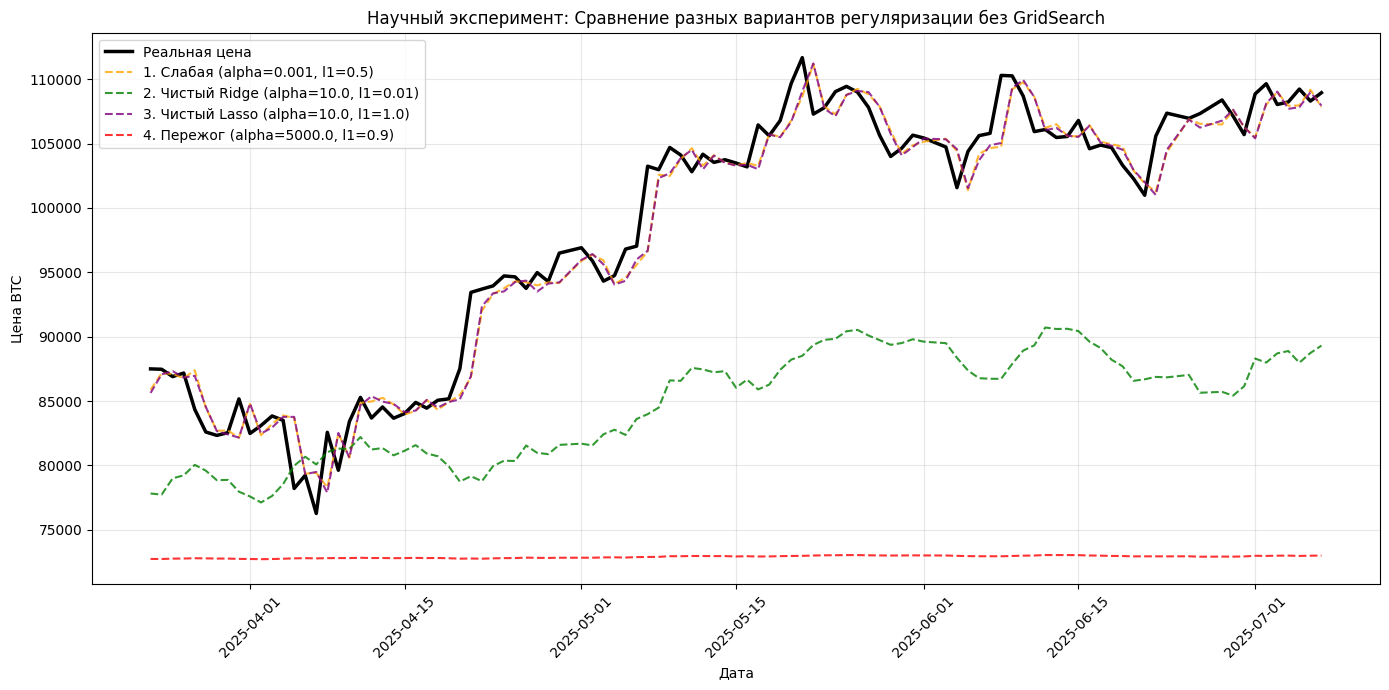

In [ ]:
#Рубрика ЭКСПЕРИМЕНТЫ
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Загрузка данных и инженерия признаков (та же, что и в эталоне)
df = pd.read_csv('../data/csv/main_data.csv')
df = df.drop_duplicates(subset=['date'], keep='first').reset_index(drop=True)
df = df[df['date'] >= '2024-01-01'].copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

df['close_change'] = df['close'].pct_change(3)
df['hash_rate_ma_7'] = df['hash-rate'].rolling(7).mean()
df['volume_ma_7'] = df['volume'].rolling(window=7).mean()
df['active_count_ma_7'] = df['active-count'].rolling(window=7).mean()
df['hash_active_count_7dirived'] = df['hash_rate_ma_7'] / (df['active_count_ma_7'] * df['volume'])
df['hash_active_count_dirived14'] = df['hash_active_count_7dirived'].rolling(window=14).mean()
df['macd_signal_diff'] = df['MACD'] - df['Signal_Line']
df['rsi_divergence'] = df['rsi'] - df['close']

features_to_lag = ['close', 'volume', 'rsi', 'MACD_Cross_Power_Normalized', 
                   'hash-rate', 'active-count', 'total_fee', 'transfer_count']

def create_lag_features(data, columns, n_lags=4):
    d = data.copy()
    for col in columns:
        for lag in range(1, n_lags+1):
            d[f'{col}_lag_{lag}'] = d[col].shift(lag)
    return d

df = create_lag_features(df, features_to_lag)
df['target_close'] = df['close'].shift(-1)
df = df.dropna()

selected_features = [
    'hash_active_count_dirived14', 'rsi', 'MACD_Cross_Power_Normalized', 
    'macd_signal_diff', 'rsi_divergence'
]
lag_cols = [col for col in df.columns if '_lag_' in col]
selected_features.extend(lag_cols)

X = df[selected_features]
y = df['target_close']

train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
test_dates = df.iloc[train_size:]['date']

# 2. Задаем варианты для ручного тестирования (без GridSearchCV)
manual_variants = {
    "1. Слабая (alpha=0.001, l1=0.5)": {'alpha': 0.001, 'l1_ratio': 0.5},
    "2. Чистый Ridge (alpha=10.0, l1=0.01)": {'alpha': 10.0, 'l1_ratio': 0.01},
    "3. Чистый Lasso (alpha=10.0, l1=1.0)": {'alpha': 10.0, 'l1_ratio': 1.0},
    "4. Пережог (alpha=5000.0, l1=0.9)": {'alpha': 5000.0, 'l1_ratio': 0.9}
}

predictions_dict = {}

print("Запуск ручных экспериментов без GridSearch...")
for name, params in manual_variants.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=params['alpha'], l1_ratio=params['l1_ratio'], random_state=42, max_iter=50000))
    ])
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    score = r2_score(y_test, preds)
    
    predictions_dict[name] = preds
    print(f"[{name}] -> R²: {score:.4f}")

# 3. Визуализация всех вариантов на одном графике
plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test.values, label='Реальная цена', color='black', linewidth=2.5)

colors = ['orange', 'green', 'purple', 'red']
for (name, preds), color in zip(predictions_dict.items(), colors):
    plt.plot(test_dates, preds, label=name, alpha=0.8, color=color, linestyle='--')

plt.xlabel('Дата')
plt.ylabel('Цена BTC')
plt.title('Научный эксперимент: Сравнение разных вариантов регуляризации без GridSearch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('elasticnet_manual_variants.png')
print("\nГрафик сохранен как 'elasticnet_manual_variants.png'")